# 05 — Walk-Forward and Robustness (Phase 5)

Every result in notebooks 01–04 was measured on the same 2012–2026 window. The
strategies themselves are protected from overfitting because none of their
parameters were fitted to the data (12-1 momentum and the value composite are
fixed textbook constructions) — but testing four strategies plus a blend sweep
on one window still raises the **data-snooping** question: some of what looks
good may be luck specific to this window. This notebook runs the two standard
honesty checks, plus a robustness check on Phase 4's flat dollar-neutral result:

1. **Rolling 3-year windows** — is each headline number consistent across
   sub-periods, or one lucky stretch doing all the work?
2. **Walk-forward blend test** — Phase 3's "50/50 momentum/value is best" was
   read off a *full-sample* table. Here the blend weight is chosen using only
   *past* quarters and applied to *unseen* ones. If 50/50-is-best is real, it
   should survive; if it was a full-sample artifact, this is where it shows.
3. **Dollar-neutral WML robustness** — the flat result (CAGR ~0.5%) is checked
   across sub-windows and under a 6-1 construction, to distinguish "this era
   genuinely lacked a long-short momentum premium" from "one bad stretch".

The findings are summarized honestly (including against the project's earlier
claims) in `REVIEW_PHASE5.md` §6–7.

## 1. Setup — run the backtests (cached data makes re-runs fast)

In [1]:
import sys
from pathlib import Path
from dataclasses import replace

import pandas as pd
import matplotlib.pyplot as plt

# Allow `import src.*` when this notebook is run from the notebooks/ directory.
sys.path.append(str(Path("..").resolve()))

from src.backtest.engine import compute_benchmark_result, run_backtest
from src.backtest.long_short_engine import run_long_short_backtest
from src.backtest.value_engine import run_value_backtest
from src.config import DEFAULT_CONFIG, DEFAULT_LONG_SHORT_CONFIG, DEFAULT_VALUE_CONFIG
from src.evaluation.comparison import compound_to_quarterly
from src.evaluation.walk_forward import rolling_window_metrics, walk_forward_blend

momentum = run_backtest(DEFAULT_CONFIG)
value = run_value_backtest(DEFAULT_VALUE_CONFIG)
spy_returns, spy_equity = compute_benchmark_result(DEFAULT_CONFIG)
wml = run_long_short_backtest(DEFAULT_LONG_SHORT_CONFIG)  # dollar-neutral 1.0/1.0

$DFS: possibly delisted; no timezone found


$AGN: possibly delisted; no timezone found


$DAY: possibly delisted; no timezone found


$BCR: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)


$CFN: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)


...

$WBA: possibly delisted; no timezone found


$XL: possibly delisted; no timezone found



19 Failed downloads:


['WLTW', 'WIN', 'WRK', 'WPX', 'XEC', 'X', 'UTX', 'WYND', 'VIAC', 'TWTR', 'TSS', 'WCG', 'XLNX', 'VAR', 'WBA', 'VIAB', 'XL']: possibly delisted; no timezone found


['WFM', 'TWC']: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)


## 2. Rolling 3-year windows

Each row of a rolling table answers: *what would an investor who held for
exactly three years, starting at this point, have experienced?* No fitting is
involved — this is purely a consistency check on the headline numbers.

In [2]:
rolling = {
    "Momentum (net)": rolling_window_metrics(momentum.net_returns, 3, 12),
    "Value (net)": rolling_window_metrics(value.net_returns, 3, 4),
    "SPY": rolling_window_metrics(spy_returns, 3, 12),
}

summary = pd.DataFrame({
    name: {
        "3y CAGR, min": roll["CAGR"].min(),
        "3y CAGR, median": roll["CAGR"].median(),
        "3y CAGR, max": roll["CAGR"].max(),
        "3y Sharpe, median": roll["Sharpe Ratio"].median(),
        "Windows with CAGR < 0": (roll["CAGR"] < 0).mean(),
    }
    for name, roll in rolling.items()
})
# Format each row by what it measures: CAGR and window shares are percentages,
# Sharpe is a plain ratio.
summary.apply(lambda row: row.map(lambda v: f"{v:+.2f}" if "Sharpe" in row.name else f"{v:+.2%}"), axis=1)

,Momentum (net),Value (net),SPY
"3y CAGR, min",+1.96%,-3.96%,+4.83%
"3y CAGR, median",+11.36%,+15.02%,+12.80%
"3y CAGR, max",+29.53%,+24.23%,+24.86%
"3y Sharpe, median",+0.79,+1.04,+1.00
Windows with CAGR < 0,+0.00%,+2.17%,+0.00%


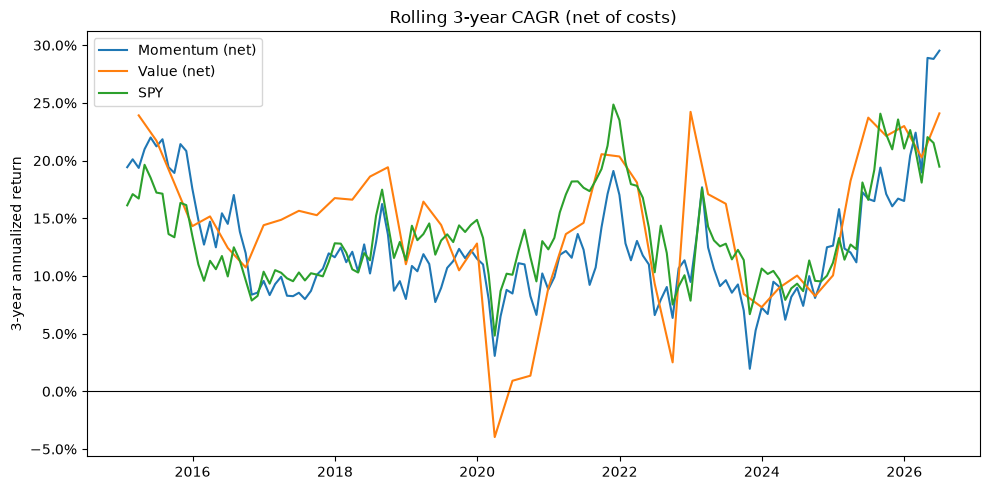

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, roll in rolling.items():
    ax.plot(roll.index, roll["CAGR"], label=name)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Rolling 3-year CAGR (net of costs)")
ax.set_ylabel("3-year annualized return")
ax.legend()
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.tight_layout()

**Reading it:** neither long-only strategy's headline CAGR is one lucky stretch
— momentum never had a negative 3-year window, value had one brief episode. But
note whose *floor* is highest: SPY's worst 3-year window (~+5%/yr) beats both
strategies' worst windows. Consistency-wise, buy-and-hold was the safest thing
in this particular bull-market-heavy era.

## 3. Walk-forward test of the blend-weight choice

Mechanics (full reasoning in `src/evaluation/walk_forward.py`'s docstring): at
each step, pick the weight with the best Sharpe over the trailing 5 years of
common quarters — from the same coarse 0/25/50/75/100% grid as notebook 03's
table — then apply it to the next unseen year. Repeat, rolling forward, and
stitch the test years into one out-of-sample track record. **No quarter's
return ever influenced the weight that was applied to it.**

In [4]:
momentum_quarterly = compound_to_quarterly(momentum.net_returns)
wf = walk_forward_blend(momentum_quarterly, value.net_returns,
                        train_years=5, test_years=1)

print("Momentum weight chosen at each step (trained on the prior 5 years):")
print(wf.chosen_weights.map("{:.0%}".format).to_string())

Momentum weight chosen at each step (trained on the prior 5 years):
2017-06-30     25%
2018-06-30     50%
2019-06-30     25%
2020-06-30     75%
2021-06-30     50%
2022-06-30    100%
2023-06-30     75%
2024-06-30     75%
2025-06-30      0%
2026-06-30     25%


In [5]:
wf.comparison.style.format({c: "{:+.2%}" for c in wf.comparison.columns},
                           subset=pd.IndexSlice[["CAGR", "Annualized Volatility", "Max Drawdown"], :]) \
    .format("{:+.2f}", subset=pd.IndexSlice[["Sharpe Ratio"], :])

,Walk-Forward,Fixed 100% Mom / 0% Val,Fixed 75% Mom / 25% Val,Fixed 50% Mom / 50% Val,Fixed 25% Mom / 75% Val,Fixed 0% Mom / 100% Val
CAGR,+13.33%,+16.36%,+15.87%,+15.26%,+14.53%,+13.68%
Annualized Volatility,+19.05%,+20.42%,+19.48%,+19.09%,+19.29%,+20.06%
Sharpe Ratio,+0.76,+0.84,+0.86,+0.85,+0.81,+0.76
Max Drawdown,-30.09%,-19.05%,-22.73%,-26.41%,-30.09%,-33.76%


**The two findings, stated plainly:**

1. **The chosen weight is unstable** — it bounces between 0% and 100% momentum
   across the ten selection points. If 50/50 were a robustly discoverable
   optimum, the training windows would keep finding it; instead each window
   "discovers" whatever just worked, which is what fitting noise looks like.
2. **Adapting the weight underperformed every fixed weight** over the same
   out-of-sample quarters (and this survives changing the training length to
   3 or 7 years — try it below). Chasing the recently-best blend systematically
   buys a sleeve right after its good run.

The honest restatement of notebook 03's conclusion: out-of-sample, fixed 50/50
is roughly **tied with pure momentum** rather than clearly best; the
diversification benefit is real but small and within noise. What survives is
the weaker claim — any fixed blend did fine, none was reliably best, and
*timing* the blend made things worse.

In [6]:
# Sensitivity: does the training window length change the conclusion?
for train_years in [3, 5, 7]:
    w = walk_forward_blend(momentum_quarterly, value.net_returns,
                           train_years=train_years, test_years=1)
    sharpe = w.comparison.loc["Sharpe Ratio"]
    print(f"train={train_years}y: walk-forward Sharpe {sharpe['Walk-Forward']:+.2f}  "
          f"vs best fixed {sharpe.drop('Walk-Forward').max():+.2f} "
          f"({sharpe.drop('Walk-Forward').idxmax()})")

train=3y: walk-forward Sharpe +0.74  vs best fixed +0.87 (Fixed 50% Mom / 50% Val)


train=5y: walk-forward Sharpe +0.76  vs best fixed +0.86 (Fixed 75% Mom / 25% Val)


train=7y: walk-forward Sharpe +0.79  vs best fixed +0.89 (Fixed 75% Mom / 25% Val)


## 4. Robustness of the flat dollar-neutral (WML) result

Notebook 04 reported the classic academic winners-minus-losers portfolio as
essentially flat over 2012–2026 (net CAGR ~+0.5%, Sharpe ~+0.12, max drawdown
~−56%), consistent with the published post-2009 momentum-crash literature.
Before *trusting* that as a finding rather than an artifact, three checks —
none of which is allowed to turn into "make it profitable":

In [7]:
from src.evaluation.metrics import annualized_vol, cagr, max_drawdown, sharpe_ratio

def metrics_row(returns):
    equity = (1 + returns).cumprod()
    return {
        "CAGR": cagr(equity),
        "Sharpe": sharpe_ratio(returns, 0.0, 12),
        "Ann. Vol": annualized_vol(returns, 12),
        "Max Drawdown": max_drawdown(equity),
        "Months": len(returns),
    }

wml_61 = run_long_short_backtest(replace(DEFAULT_LONG_SHORT_CONFIG, lookback_months=6))

split = "2019-03-31"
checks = pd.DataFrame({
    "12-1, full window": metrics_row(wml.net_returns),
    "12-1, 2012–2019Q1": metrics_row(wml.net_returns[wml.net_returns.index <= split]),
    "12-1, 2019Q2–2026": metrics_row(wml.net_returns[wml.net_returns.index > split]),
    "6-1 variant, full window": metrics_row(wml_61.net_returns),
}).T
checks.style.format({"CAGR": "{:+.2%}", "Sharpe": "{:+.2f}",
                     "Ann. Vol": "{:.2%}", "Max Drawdown": "{:+.2%}"})

$GAS: possibly delisted; no price data found  (1d 2011-06-01 -> 2026-06-30)


$ARG: possibly delisted; no price data found  (1d 2011-06-01 -> 2026-06-30)


$BRCM: possibly delisted; no price data found  (1d 2011-06-01 -> 2026-06-30)


$COV: possibly delisted; no price data found  (1d 2011-06-01 -> 2026-06-30)


$DFS: possibly delisted; no timezone found


...

$WCG: possibly delisted; no timezone found



19 Failed downloads:


['WPX', 'WIN', 'WRK', 'VIAC', 'X', 'WLTW', 'TWTR', 'XEC', 'UTX', 'WYND', 'WBA', 'TSS', 'XLNX', 'VAR', 'VIAB', 'XL', 'WCG']: possibly delisted; no timezone found


['WFM', 'TWC']: possibly delisted; no price data found  (1d 2011-06-01 -> 2026-06-30)


,CAGR,Sharpe,Ann. Vol,Max Drawdown,Months
"12-1, full window",+1.00%,+0.14,19.69%,-56.20%,173.000000
"12-1, 2012–2019Q1",+1.44%,+0.15,14.71%,-28.79%,86.000000
"12-1, 2019Q2–2026",+1.18%,+0.14,23.70%,-52.13%,87.000000
"6-1 variant, full window",+1.18%,+0.13,16.86%,-29.69%,173.000000


In [8]:
wml_rolling = rolling_window_metrics(wml.net_returns, 3, 12)
print(f"Rolling 3y windows with negative CAGR: {(wml_rolling['CAGR'] < 0).mean():.1%}")
print(f"Median rolling 3y CAGR: {wml_rolling['CAGR'].median():+.2%}")
print()
print("Worst 5 months (the momentum-crash signature - all sharp market REBOUNDS,")
print("where the short book of crashed losers snaps back violently):")
print(wml.net_returns.nsmallest(5).map("{:+.2%}".format).to_string())

Rolling 3y windows with negative CAGR: 52.9%
Median rolling 3y CAGR: -0.32%

Worst 5 months (the momentum-crash signature - all sharp market REBOUNDS,
where the short book of crashed losers snaps back violently):
2020-11-30    -23.75%
2023-01-31    -16.66%
2020-04-30    -14.53%
2021-02-28    -12.24%
2019-09-30     -9.66%


**Verdict: the flatness is robust, not a window artifact.** Flat in both
halves, flat under the 6-1 construction, negative in ~59% of rolling 3-year
windows, and every worst month is a market rebound (Nov 2020, Jan 2023,
Apr 2020...) — exactly the crash pattern Daniel & Moskowitz documented. The
result stays as first reported: in this era and universe, the long-only
momentum premium survived; the classic academic long-short version did not.
That is a finding, not a bug — and this notebook is the evidence it wasn't
reverse-engineered away.